In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import json
import os

from Encoder import*
from Tools.model_tools import load_configs
from Tools.data_utils import extract_params_from_filename
from Tools.mathematical_tools import denormalize_columns, diagonal_mean
from Tools.analysis_tools import*

### Validation Dataset for Encoder:

In this Notebook we will test the performance of the Encoder and the Dummy Decoder to reconstruct the input observable $y_1(t) = z_2(t) + \beta \cdot \sigma$ . This method allow the Encoder to learn a meaningful and solid latent rapresentation of the sistem.

In [2]:
# Percorso del database
model_database_path = "encoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_configs = load_configs(model_database_path)

# Visualizza le configurazioni disponibili
for model_name, config in all_configs.items():
    print(model_name, config)

Prova {'layer_dims': [10, 7, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,10_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}


### Input encoder:
Choose a model present in the database of the pre-trained model, insert the name to continue.

In [3]:
# Scegli un modello specifico
model_name = "Prova"  # Cambia con il nome desiderato
selected_model_config = all_configs.get(model_name)

if selected_model_config is None:
    raise ValueError(f"Il modello {model_name} non esiste nel database.")

Loading network and database from the Encoder Models folder

In [4]:
# Percorso al file del modello salvato
model_file_path = os.path.join("Encoder Models", f"{model_name}.pth")

# Carica il modello salvato
checkpoint = torch.load(model_file_path)
epoch = checkpoint['epoch']
stopped_epoch = checkpoint['stopped_epoch']
encoder_state_dict = checkpoint['encoder_state_dict']
decoder_state_dict = checkpoint['decoder_state_dict']
optimizer_state_dict = checkpoint['optimizer_state_dict']
train_data = checkpoint['train_data']
val_data = checkpoint['val_data']
encoder_layers = checkpoint['encoder_layers']
decoder_layers = checkpoint['decoder_layers']
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
recon_losses = checkpoint['recon_losses']
kld_losses = checkpoint['kld_losses']
effective_kld_losses = checkpoint['effective_kld_losses']
beta_values = checkpoint['beta_values']
gradient_history = checkpoint['gradient_history']
denormalizing_params = checkpoint['denormalizing_params']
P = checkpoint['P'] #Legendre Basis
H1= checkpoint['H1']

# Ricostruisci il modello e l'ottimizzatore

encoder = Encoder(encoder_layers)
decoder = Decoder(decoder_layers)

vae_model = VAE(encoder, decoder)
vae_model.encoder.load_state_dict(encoder_state_dict)
vae_model.decoder.load_state_dict(decoder_state_dict)
optimizer = optim.Adam(vae_model.parameters())
optimizer.load_state_dict(optimizer_state_dict)

print(f"Modello {model_name} caricato con successo.")
print(f"Training fino a epoca: {stopped_epoch if stopped_epoch else epoch}")

params = extract_params_from_filename(selected_model_config["dataset"])
print(f"Parametri del dataset di training: {params}")
tau = params["tau"]
embedding_dim = params["embedding_dim"]

/tmp/ipykernel_104369/1676129546.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_file_path)


Modello Prova caricato con successo.
Training fino a epoca: 50
Parametri del dataset di training: {'tau': 15, 'embedding_dim': 20, 'r': 10, 'alpha': 0.0, 'beta': 0.0}


In [5]:
batch_size = selected_model_config["batch_size"]

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

total_sample = len(train_data)+len(val_data)
print(f"Numero totale di campioni: {total_sample}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

Numero totale di campioni: 648
Numero di campioni di training: 388
Numero di campioni di validazione: 260


#### Training stat of the encoder:

Info about the training cicle of the Encoder

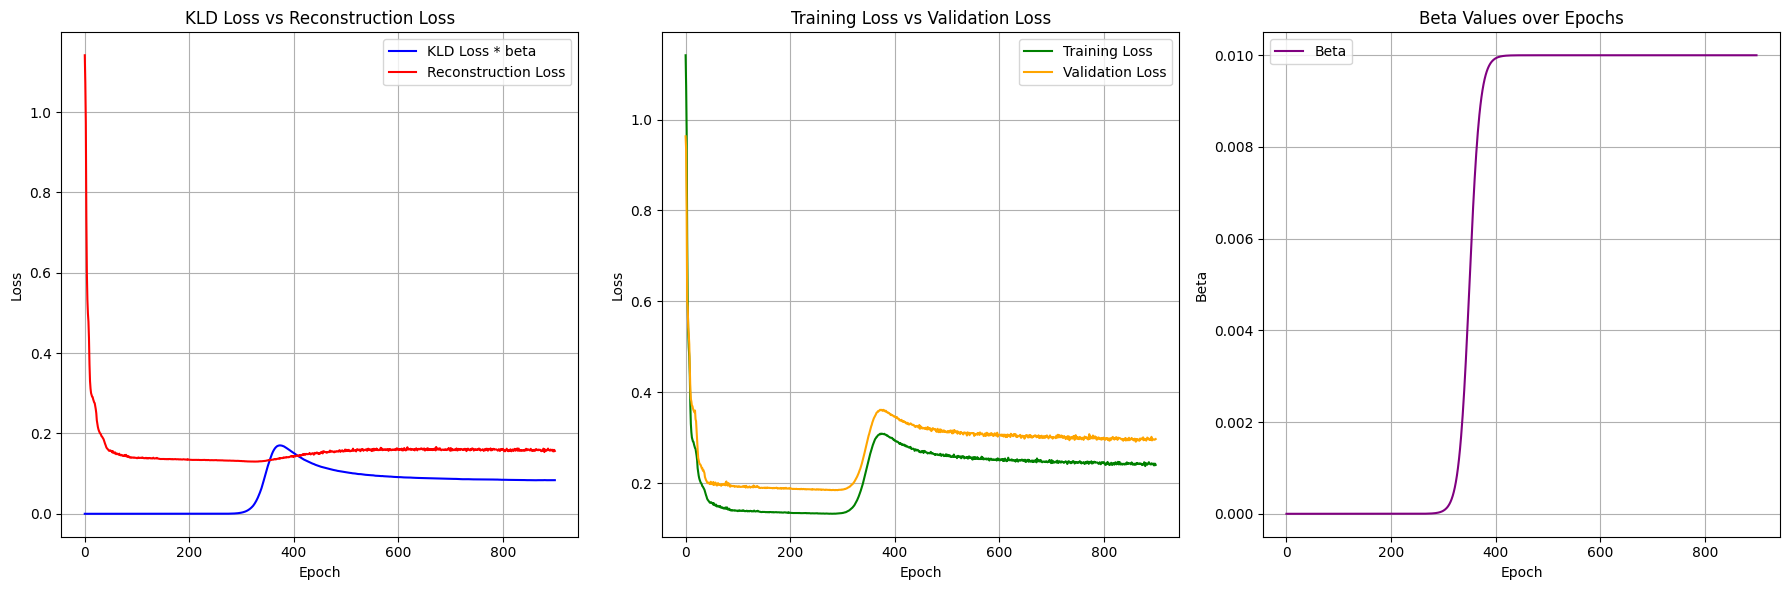

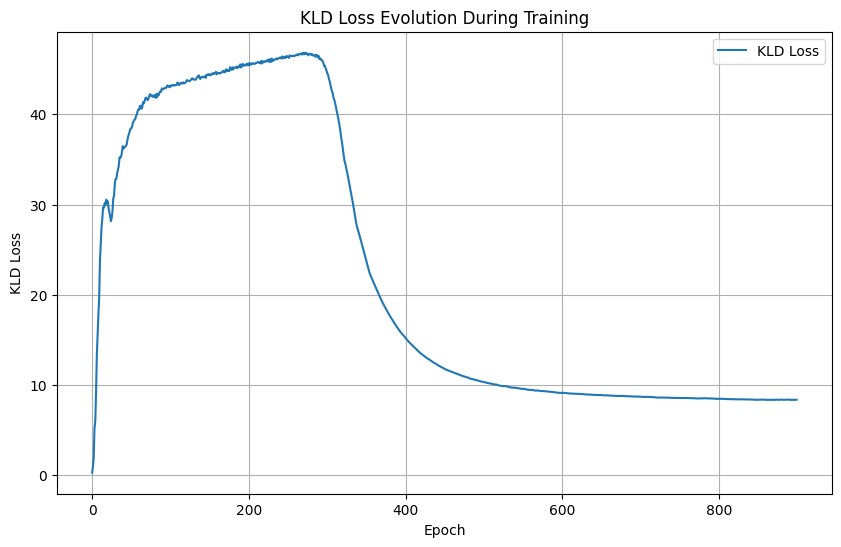

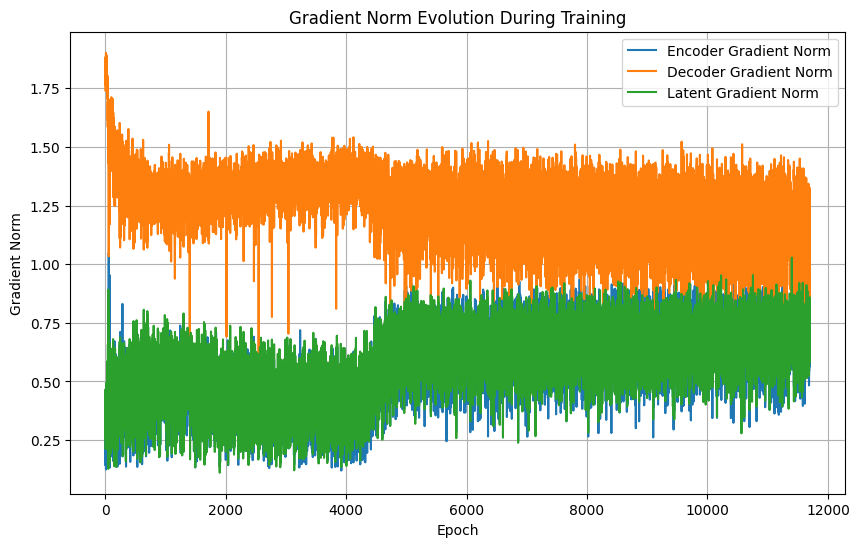

Varianza spiegata: [0.4031277  0.27740312]


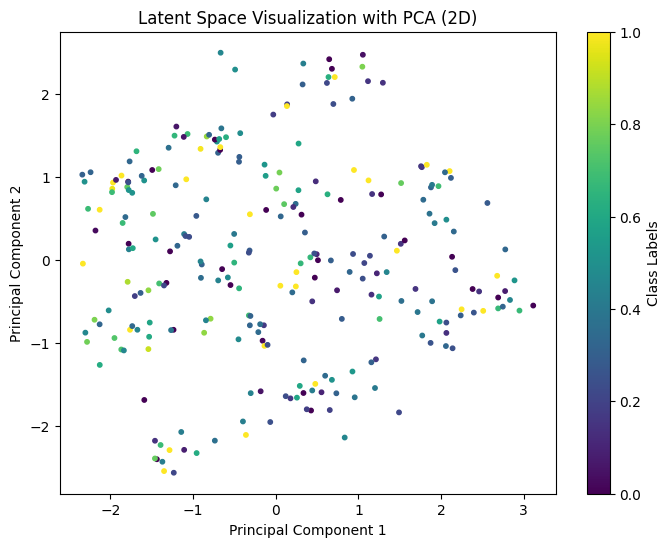

In [6]:
plot_results(train_losses, val_losses, recon_losses, kld_losses, effective_kld_losses, beta_values, gradient_history)
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

### Validation dataset:
Validation dataset is passed through the network as implemented in 'Encoder.py' class and specified in the 'trainEncoder.ipynb' Notebook.
In this section we will:

1. Post-process data to reconstruct dynamics in original dimensionality
2. Analyze raw (processed data) reconstruction and post-processed dynamic reconstruction


In [7]:
input_data, predicted_data, mean_vectors, logvar_vectors = run_model_and_collect_outputs(vae_model, val_loader, device="cpu")

predicted_data_matrix = predicted_data.T

print("Input data shape:", input_data.shape)
print("Predicted data shape:", predicted_data.shape)
print("Mean vectors shape:", mean_vectors.shape)
print("Logvar vectors shape:", logvar_vectors.shape)


# Input and target definition from the validation data
inputs, targets = zip(*[val_data[i] for i in range(len(val_data))])  # Not very useful now, but it will be in the future  

# Convert into Numpy tensor for analysis
inputs = torch.stack(inputs).numpy() 
targets = torch.stack(targets).numpy()

print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)



Input data shape: (260, 10)
Predicted data shape: (260, 10)
Mean vectors shape: (260, 5)
Logvar vectors shape: (260, 5)
Inputs shape: (260, 10)
Targets shape: (260, 10)


#### Recovering dimensionality:

Here is the code to revert the preprocessing of the data and create variables for later analysis. The step to follow are 3 and are coherent with the preprocessing : reconstruct Hankel matrix from projected Delay vectors, denormalize Matrix, revert projection from the legendre Basis.

##### Post-processing:

p = 260 for Validation Dataset
d = 20 (Embedding Dimension)

Hankel Matrix :  <br>


$ H(t) =
\begin{bmatrix}
y(t_1) & y(t_2) & y(t_3) & \cdots & y(t_(p-d+1)) \\
y(t_2) & y(t_3) & y(t_4) & \cdots & y(t+n) \\
y(t_3) & y(t_4) & y(t_5) & \cdots & y(t+n+1) \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
y(t_d) & y(t_(d+1)) & y(t_(d+2)) & \cdots & y(t_p)
\end{bmatrix}
 \in \mathbb{R}^{d \times (p-d+1)}
$


Legendre Basis Matrix: <br>


$ P^{(r)} = 
\begin{bmatrix}
P_0(x_0) & P_1(x_0) & \cdots & P_r(x_0) \\
P_0(x_1) & P_1(x_1) & \cdots & P_r(x_1) \\
P_0(x_2) & P_1(x_2) & \cdots & P_r(x_2) \\
\vdots & \vdots & \ddots & \vdots \\
P_0(x_{d-1}) &P_1(x_{d-1}) & \cdots & P_r(x_{d-1})
\end{bmatrix}
 \in \mathbb{R}^{d \times r}
$

Projection of Hankel into Legendre Polinomials Basis:

$\begin{equation} 
Y^T = H^T \cdot P^{(r)} \in \mathbb{R}^{ p-d+1) \times r} 
\end{equation}$

So we perform:

\begin{equation}
H^T = Y^T \cdot P^{\dagger}
\end{equation}

where $ P^{\dagger} $ is the Pseudo-Inverse of $P$



In [8]:
from numpy.linalg import pinv

# Ottieni gli indici delle colonne di validazione
validation_indices = val_data.indices
original_Hankel_Matrix = H1[:, validation_indices]

# Estrai i minimi e massimi per le colonne di validazione
validation_min_vals = denormalizing_params["min_h1"][:, validation_indices]
validation_max_vals = denormalizing_params["max_h1"][:, validation_indices]

print("Validation Min Values shape:", validation_min_vals.shape)

# Denormalizza usando i valori specifici
predicted_data_matrix = denormalize_columns(predicted_data_matrix, validation_min_vals, validation_max_vals)

# Calcola la pseudo-inversa di P
P_pseudo_inverse = pinv(P)

# Check delle shape:
print("Legendre Basis Matrix Shape (d x r):" , P.shape)
print("Pseudo-inverse of P shape (r x d):", P_pseudo_inverse.shape)
print("Input data Matrix shape:", original_Hankel_Matrix.shape)
print("Predicted data Matrix shape:", predicted_data_matrix.shape)

# Reverse projection of the predicted Matrix using pseudo-inverse of P
predicted_reconstructed_hankel = np.dot(predicted_data_matrix.T, P_pseudo_inverse) 
predicted_reconstructed_hankel = predicted_reconstructed_hankel.T
print("Predicted Reconstructed Hankel shape:", predicted_reconstructed_hankel.shape)



Validation Min Values shape: (1, 260)
Legendre Basis Matrix Shape (d x r): (20, 10)
Pseudo-inverse of P shape (r x d): (10, 20)
Input data Matrix shape: (20, 260)
Predicted data Matrix shape: (10, 260)
Predicted Reconstructed Hankel shape: (20, 260)


### Raw input analysis:
Silly evaluation of some reconstruction metrics between input and network recon

r2_score entries: 260


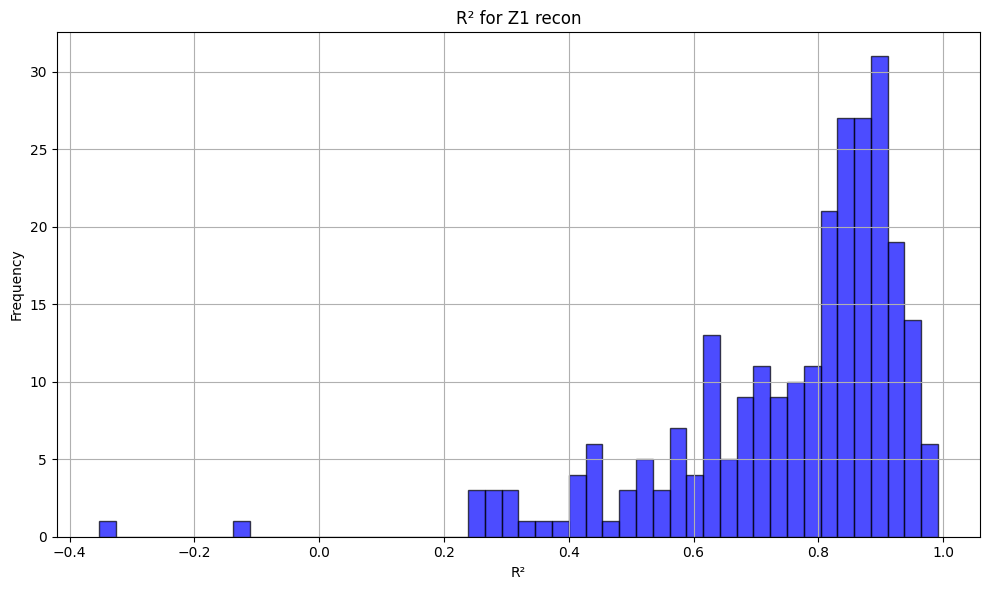

Indices of the 3 samples with the worst R² (z1): [  8   9 171]
Mean R² for Z1 recon: 0.75516415 pm 0.19224931


In [9]:
# Plot the R² histogram and get the indices of the worst R² samples
worst_r2_indices1, r2_scores1 = plot_r2_histogram(targets,predicted_data)
mean_r21 = np.mean(r2_scores1)
std_r21 = np.std(r2_scores1)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot R² histogram for Z1 recon
ax.hist(r2_scores1, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_title('R² for Z1 recon')
ax.set_xlabel('R²')
ax.set_ylabel('Frequency')
ax.grid(True)

plt.tight_layout()
plt.show()

print("Indices of the 3 samples with the worst R² (z1):", worst_r2_indices1)
print("Mean R² for Z1 recon:", mean_r21 , "pm", std_r21)




Entries: 260


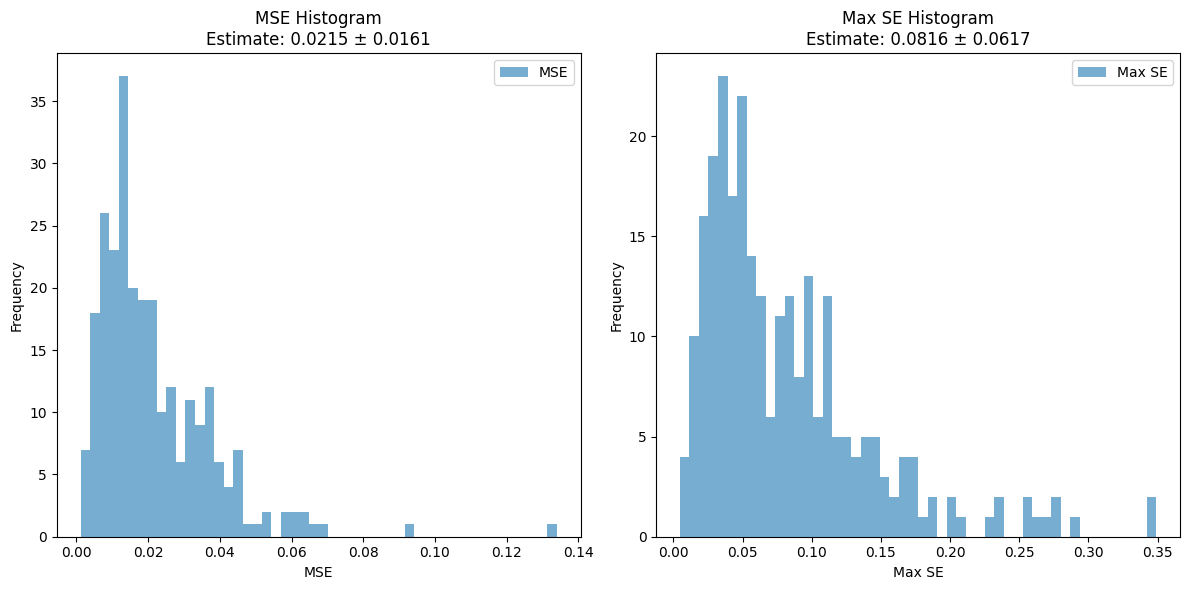

Indices of the 3 samples with the worst MAXse: [174   8   9]
Mean MSE for Z2 recon: 0.021467434 pm 0.01610595
Mean MAXse for Z2 recon: 0.08163051 pm 0.061727863


In [10]:
# Calculate errors and plot histogram for Z1 recon
worst_max_se_indices1, best_mse_indices1, mse_errors1, max_se_errors1 = calculate_errors_and_plot_hist(targets, predicted_data)
mean_mse = mse_errors1.mean()
std_mse = mse_errors1.std()
mean_max_se = max_se_errors1.mean()
std_max_se = max_se_errors1.std()
print("Indices of the 3 samples with the worst MAXse:", worst_max_se_indices1)

print("Mean MSE for Z2 recon:", mean_mse , "pm", std_mse)
print("Mean MAXse for Z2 recon:", mean_max_se , "pm", std_max_se)


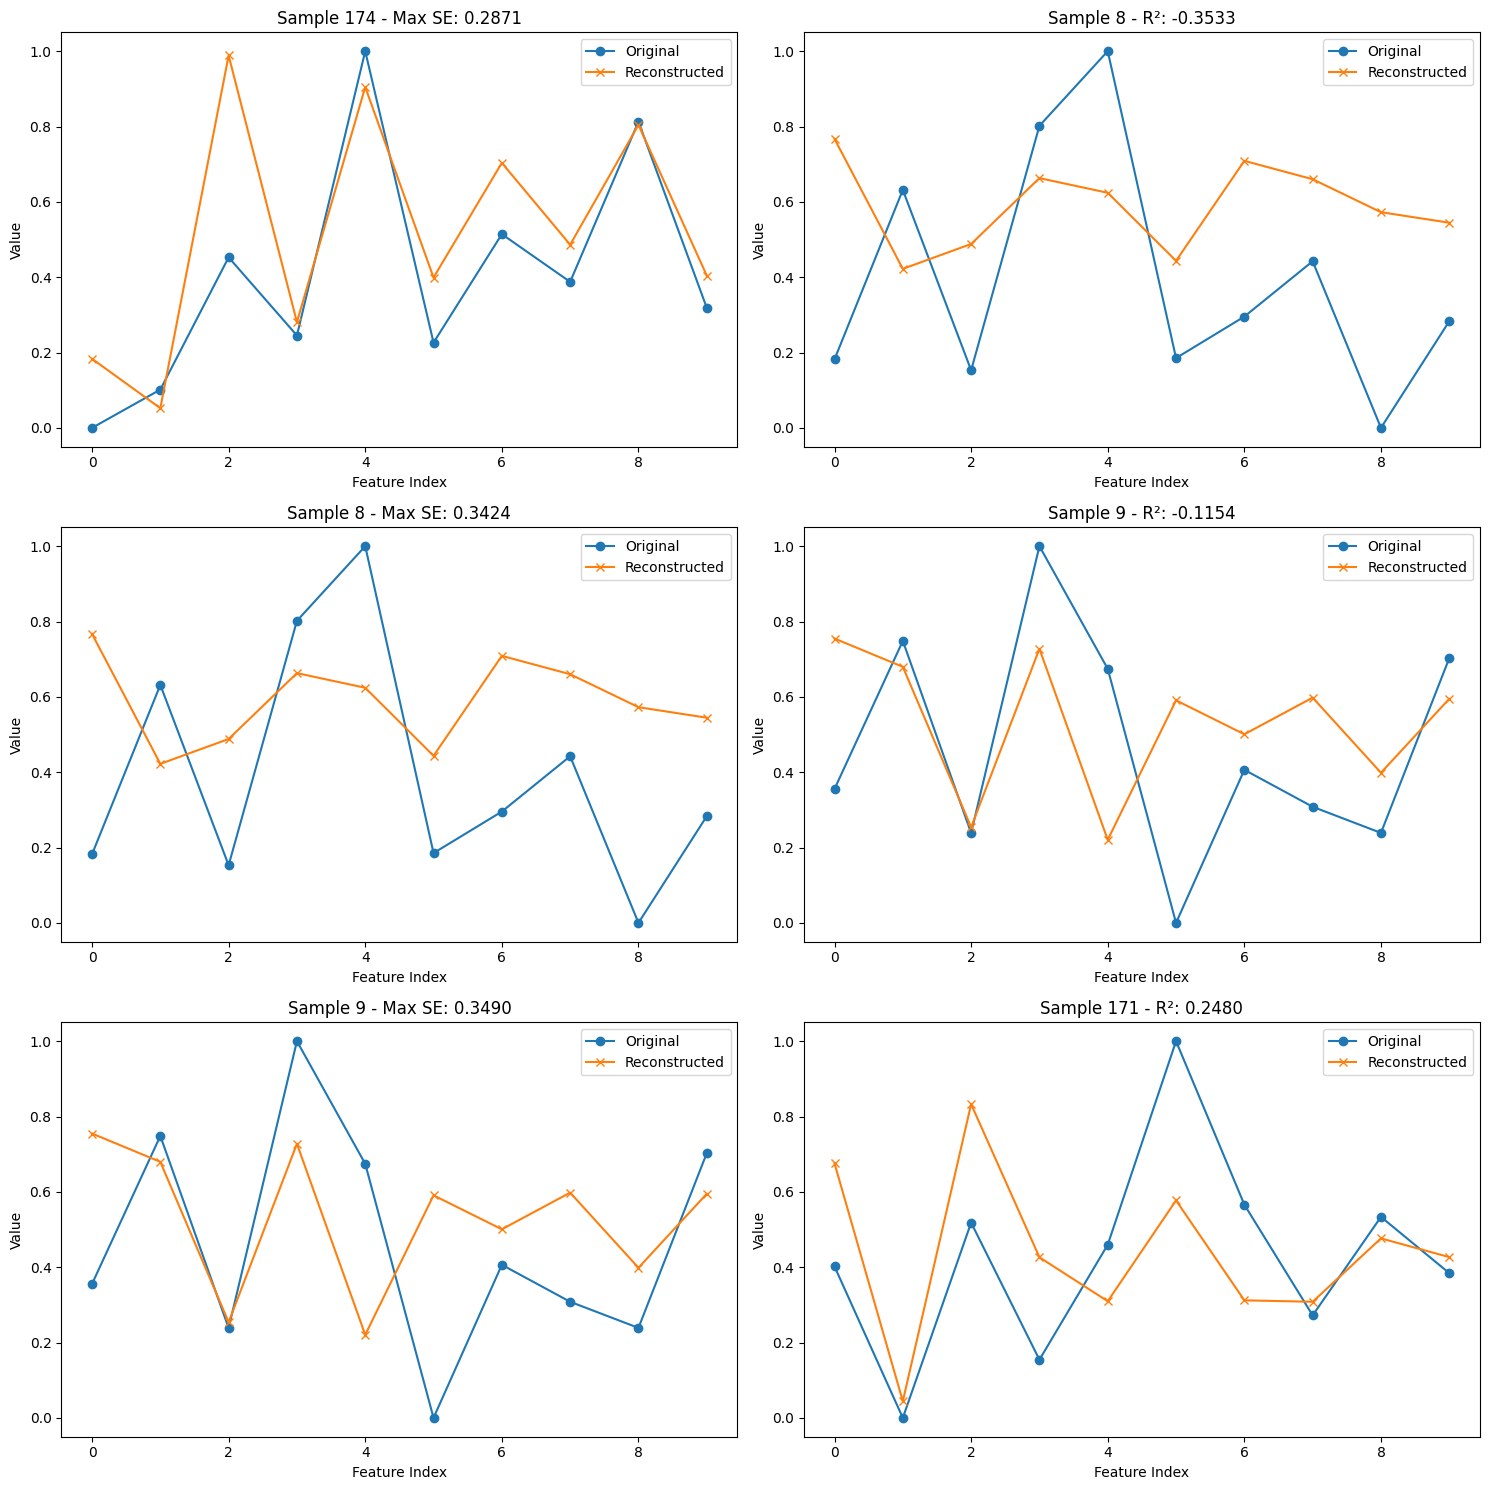

In [11]:
# Plot the reconstructed vs original for the worst three samples for max SE and R²
fig, axes = plt.subplots(3, 2, figsize=(15, 15))  # Adjusted figsize to make the plot larger

# Plot for worst three samples for max SE
for i, idx in enumerate(worst_max_se_indices1):

    original = targets[idx]
    reconstructed = predicted_data[idx]
    
    axes[i, 0].plot(original, label='Original', marker='o')
    axes[i, 0].plot(reconstructed, label='Reconstructed', marker='x')
    axes[i, 0].set_title(f'Sample {idx} - Max SE: {max_se_errors1[idx]:.4f}')
    axes[i, 0].set_xlabel('Feature Index')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].legend()

# Plot for worst three samples for R²
for i, idx in enumerate(worst_r2_indices1):
    original = targets[idx]
    reconstructed = predicted_data[idx]
    
    axes[i, 1].plot(original, label='Original', marker='o')
    axes[i, 1].plot(reconstructed, label='Reconstructed', marker='x')
    axes[i, 1].set_title(f'Sample {idx} - R²: {r2_scores1[idx]:.4f}')
    axes[i, 1].set_xlabel('Feature Index')
    axes[i, 1].set_ylabel('Value')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


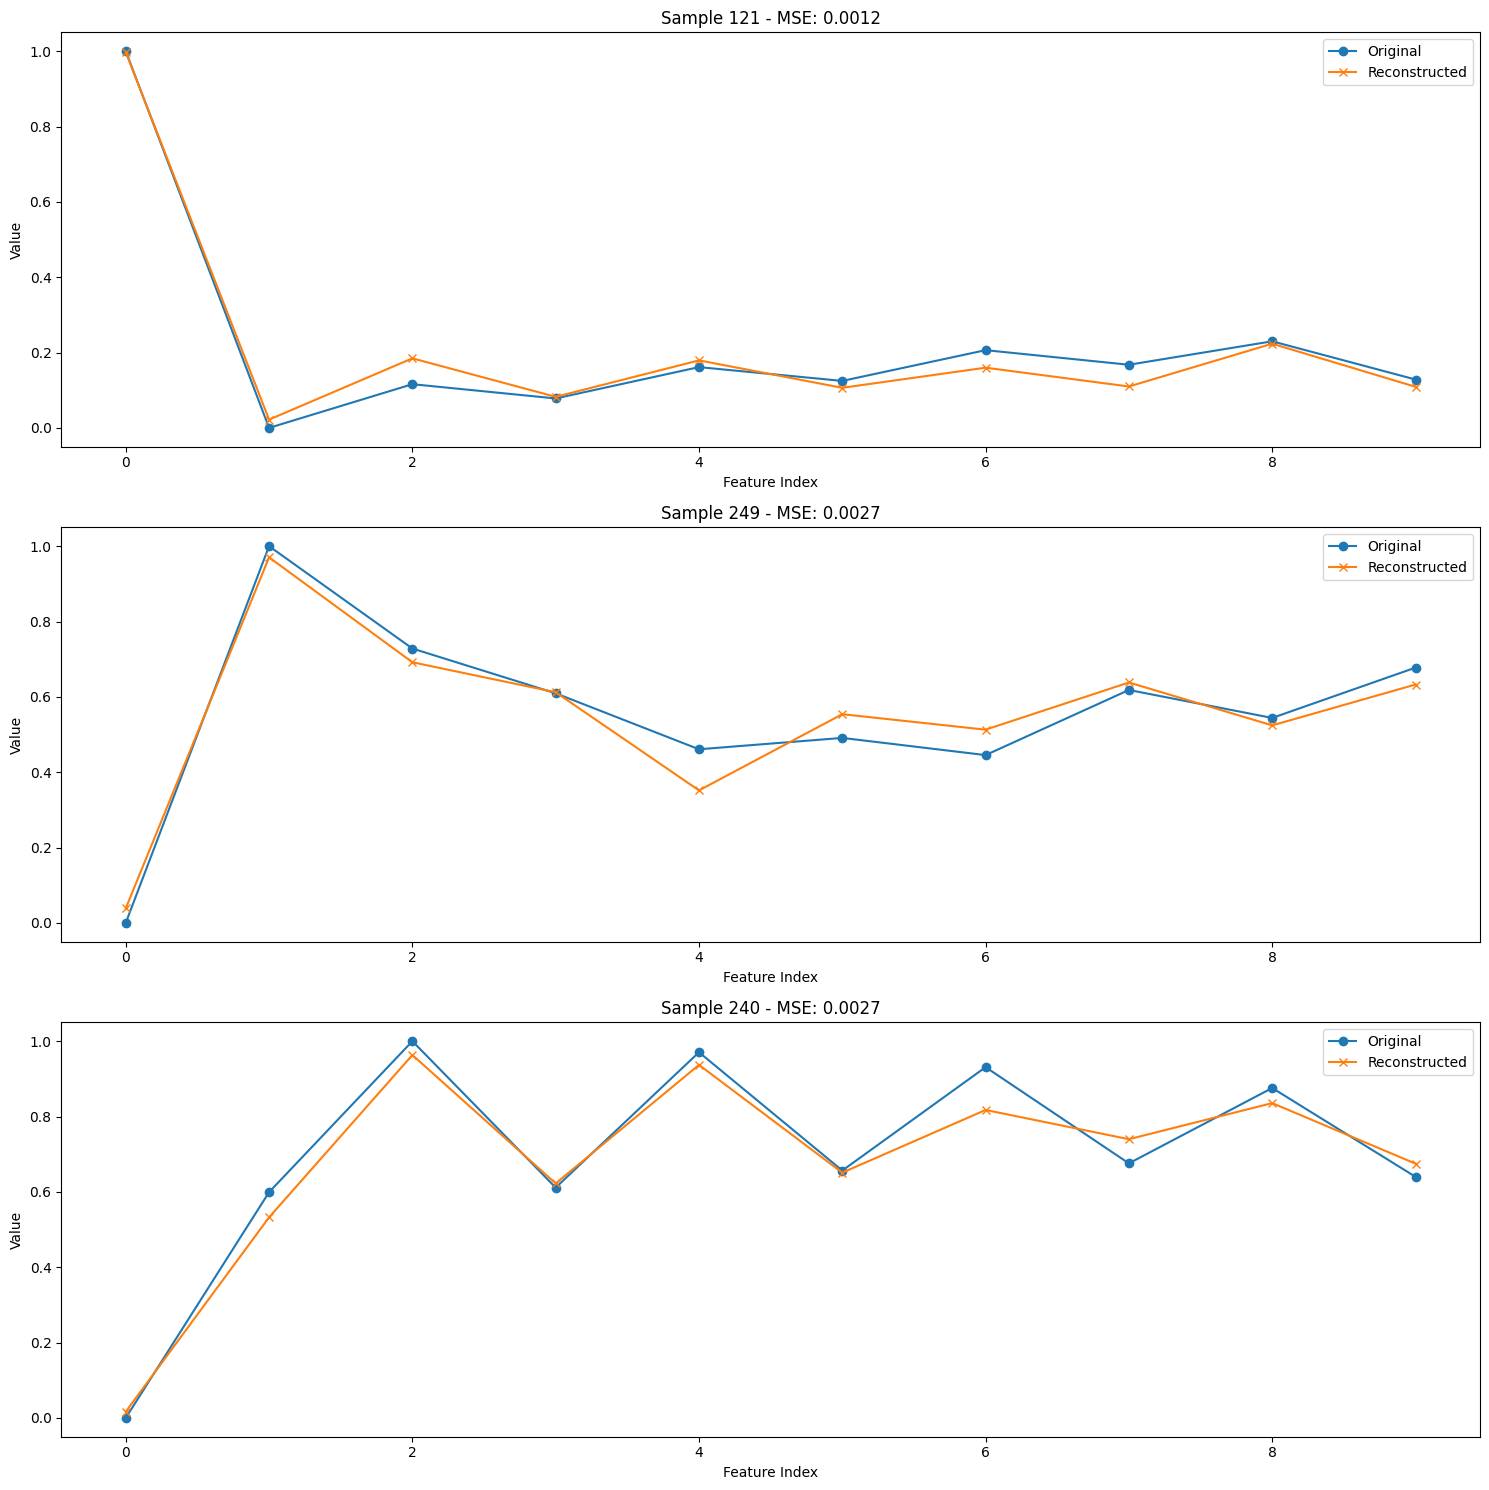

In [12]:
# Plot the reconstructed vs original for the best three samples for MSE
fig, axes = plt.subplots(3, 1, figsize=(15, 15))  # Adjusted figsize to make the plot larger

# Plot for best three samples for MSE
for i, idx in enumerate(best_mse_indices1):
    original = targets[idx]
    reconstructed = predicted_data[idx]
    
    axes[i].plot(original, label='Original', marker='o')
    axes[i].plot(reconstructed, label='Reconstructed', marker='x')
    axes[i].set_title(f'Sample {idx} - MSE: {mse_errors1[idx]:.4f}')
    axes[i].set_xlabel('Feature Index')
    axes[i].set_ylabel('Value')
    axes[i].legend()

plt.tight_layout()
plt.show()

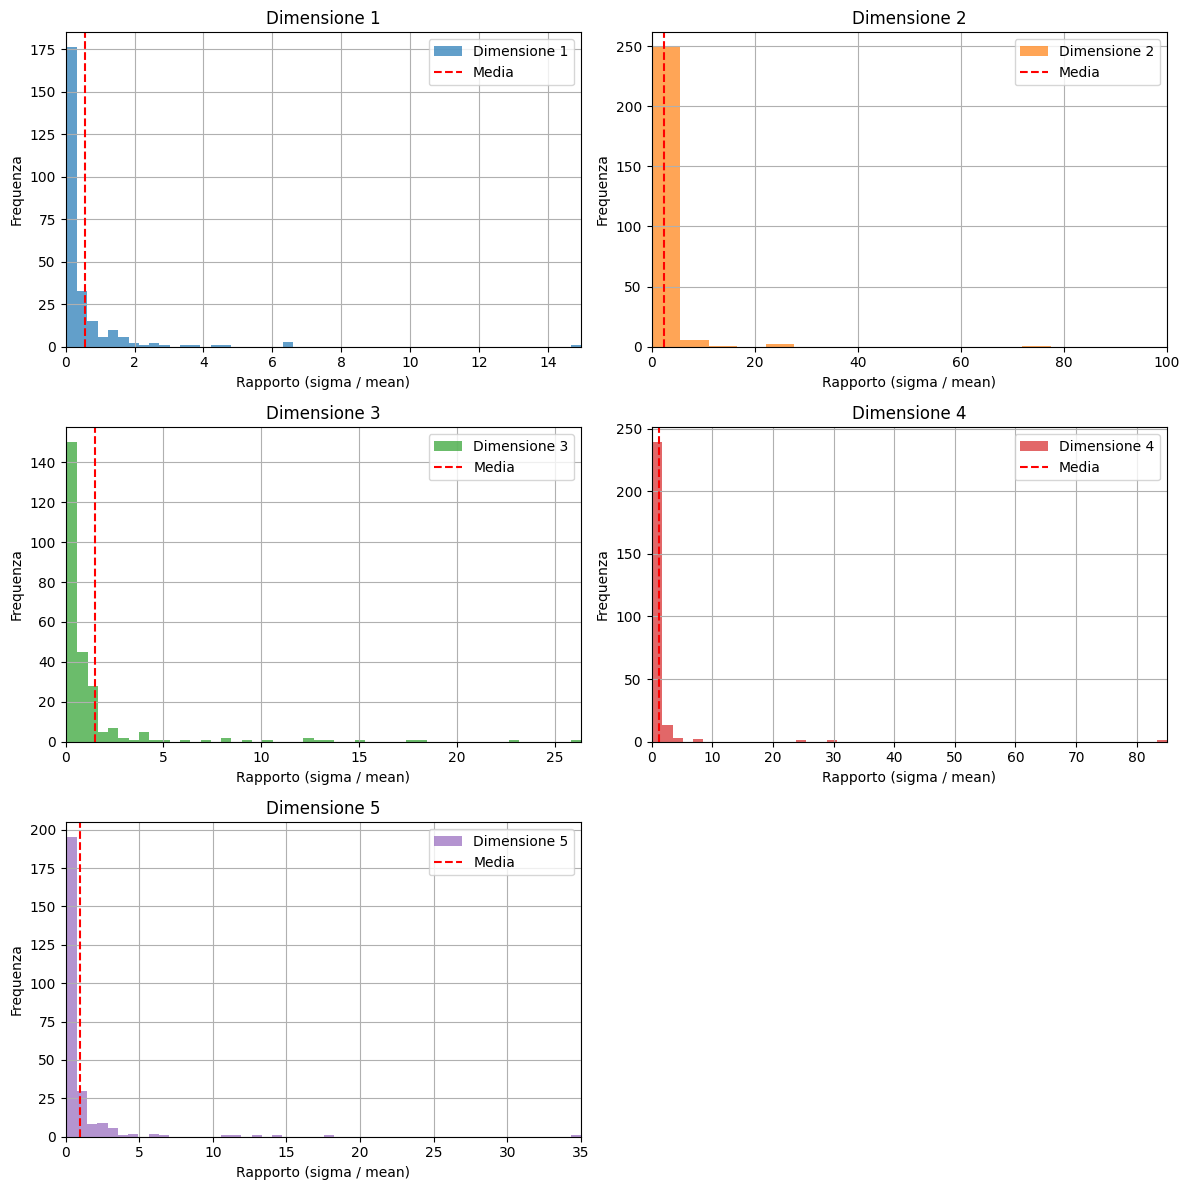

In [13]:
latent_variables(vae_model, mean_vectors, logvar_vectors, val_loader, device="cpu")

### Grafico del segnale di: $y_1(t) =z_2(t) + \beta \cdot \sigma$:
Confrontiamo il segnale temporale di $Z_2$ dal dataset di Validazione con le ricostruzioni degli output della rete.
Calcoliamo alcune metriche per valutare la ricostruzione. Vengono mediamente migliori poichè dopo aver ricostruito il segnale dagli embedding i punti anomali ripetendosi una sola volta (contro le n volte nei vettori di embedding) danno un contributo minore.

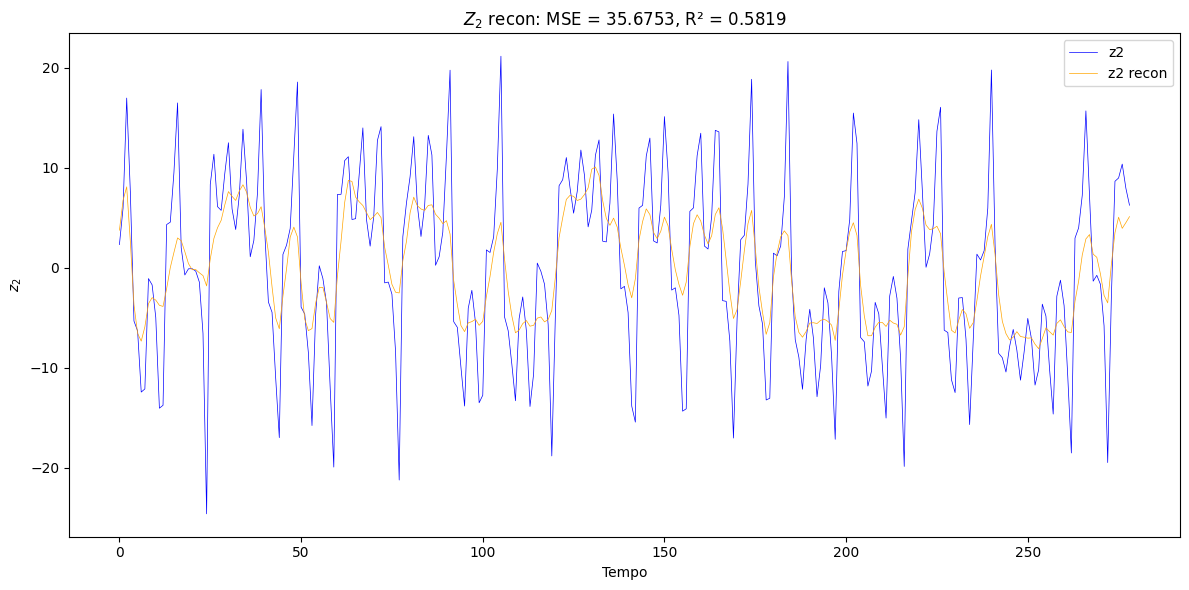

In [14]:
# Ricostruzione di Z2 dal suo embedding (Validation data)
val_Z2 = diagonal_mean(original_Hankel_Matrix)

# Ricostruzione di Z2 dal suo embedding (Ricostruito)
recon_Z2 = diagonal_mean(predicted_reconstructed_hankel)


# Calcola l'errore quadratico medio
mse1 = np.mean((val_Z2 - recon_Z2) ** 2)
r2_1 = r2_score(val_Z2, recon_Z2)
fig, ax = plt.subplots(figsize=(12, 6))

# Segnale y2(1)
ax.plot(val_Z2, label="z2", color='blue', lw=0.5)
ax.plot(recon_Z2, label="z2 recon", color='orange', lw=0.5)
ax.legend()
ax.set_title(r"$Z_2$ recon: MSE = {:.4f}, R² = {:.4f}".format(mse1, r2_1))
ax.set_xlabel("Tempo")
ax.set_ylabel("$z_2$")

plt.tight_layout()
plt.show()


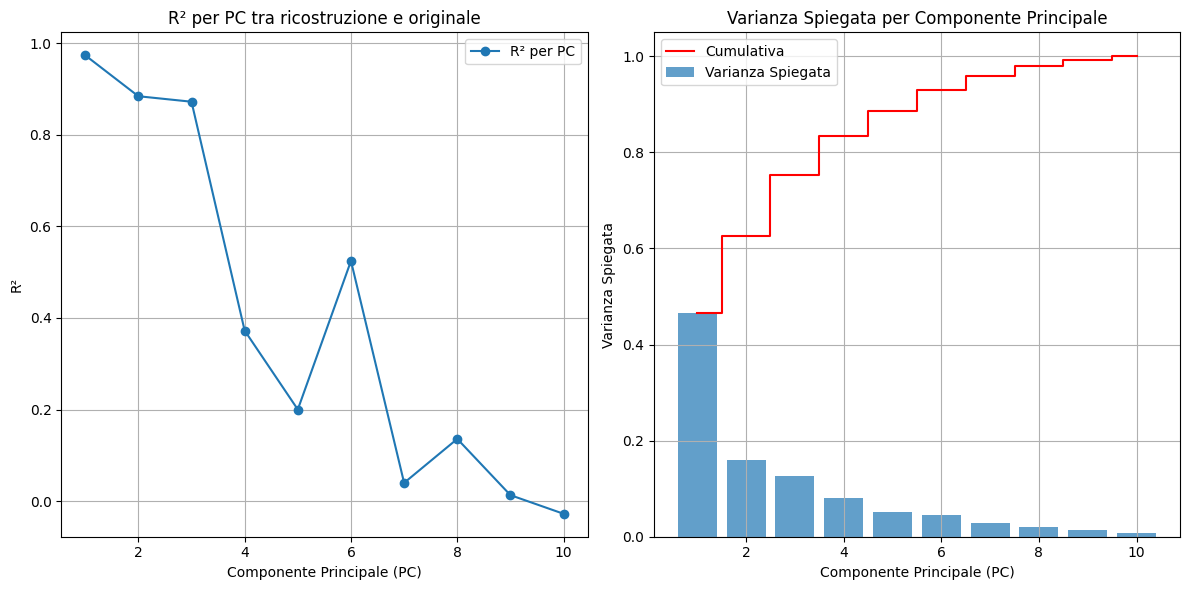

In [15]:
# Confronta PC per Z1
r2_z1, ind2 = pca_r2_analysis_embeddings(inputs, predicted_data, n_components=10)


### Ricostruzione delle PC:

In [16]:
def plot_temporal_signal_and_pcs(original_signal, original_embeddings, reconstructed_embeddings, n_components=3):
    """
    Plotta il segnale temporale originale, le PC calcolate dagli embedding originali,
    e le PC ricostruite dagli embedding di output della rete per ogni componente principale.
    
    Parameters:
        original_signal (np.ndarray): Segnale temporale originale (1D array).
        original_embeddings (np.ndarray): Embedding del segnale originale (2D array).
        reconstructed_embeddings (np.ndarray): Embedding ricostruito dalla rete (2D array).
        n_components (int): Numero di componenti principali da calcolare.
    """
    # PCA sugli embedding originali
    pca = PCA(n_components=n_components)
    pc_original = pca.fit_transform(original_embeddings)  # Tutte le PC dagli embedding originali
    pc_reconstructed = pca.transform(reconstructed_embeddings)  # Proiezione delle PC ricostruite

    # Plot per ogni componente principale
    for i in range(n_components):
        # Calcola R^2 tra la PC originale e quella ricostruita
        r2 = r2_score(pc_original[:, i], pc_reconstructed[:, i])

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(original_signal, label='Input signal', color='black', lw=1.5)
        plt.plot(pc_original[:, i], label=f'PC{i+1} ', color='orange', lw=1.5)
        plt.plot(pc_reconstructed[:, i], label=f'PC{i+1} recon', linestyle='--', color='blue', alpha=0.7, lw=1.5)
        plt.title(f"Confronto tra Segnale Temporale e PC{i+1} Ricostruite - $R^2$: {r2:.2f}")
        plt.xlabel("Time (t)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()


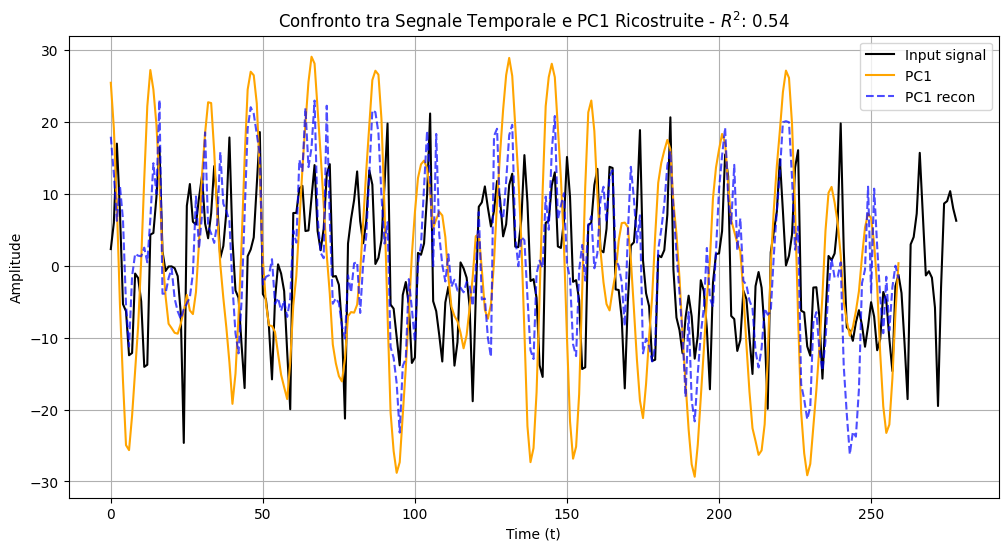

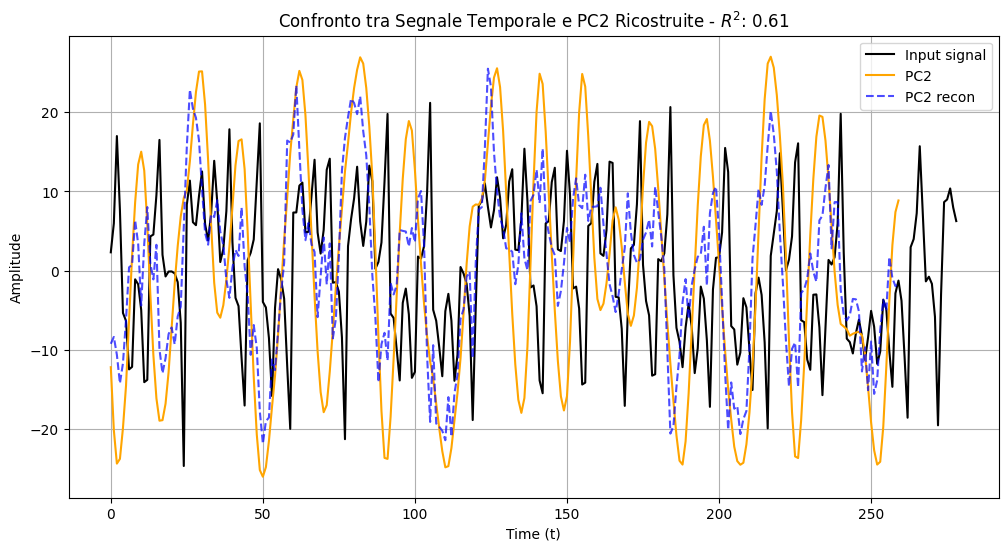

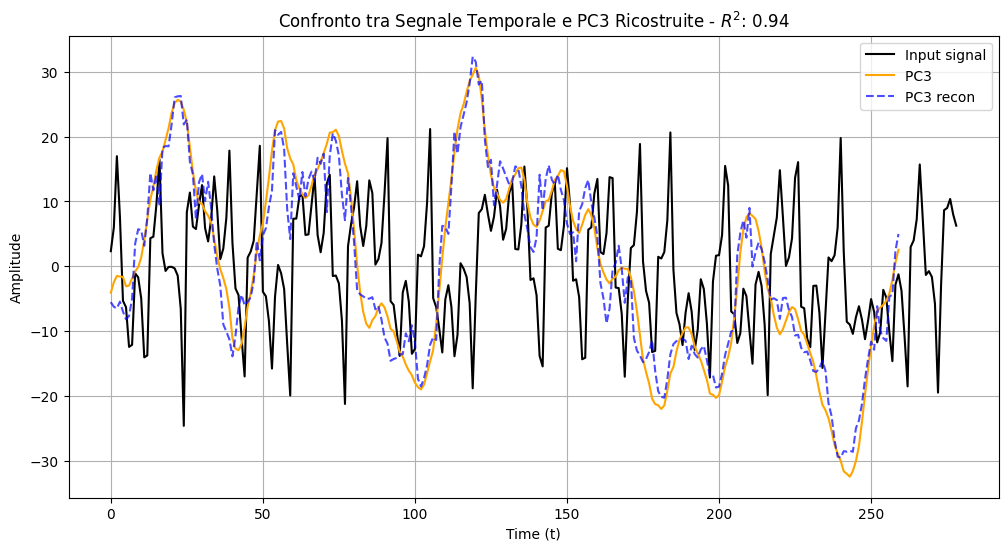

In [19]:
plot_temporal_signal_and_pcs(val_Z2, original_Hankel_Matrix.T, predicted_reconstructed_hankel.T, n_components=3)

In [18]:
output_path = "Encoder Analysis Data"
output_path += f"/{model_name}"
output_path += ".csv"

print (output_path)

save_encoder_analysis_data(model_name=model_name, 
                   latent_dim = selected_model_config["latent_dim"], 
                   r2_mean = mean_r21, r2_std = std_r21, 
                   mse_mean = mean_mse, mse_std = std_mse, 
                   maxse_mean = mean_max_se, maxse_std = std_max_se,
                   r2_z2= r2_z1, ind1= ind2,
                   r2_t_Z2= r2_1,
                   file_path=output_path)

Encoder Analysis Data/Prova.csv
Analysis data saved to Encoder Analysis Data/Prova.csv
